<a href="https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/models/deep_learning/DLinear/model_experiment_DLinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DLinear hyperparameter tuning — best architecture v1

Best manual DLinear architecture so far:

```text
DLinear + Store-Dept series_bias
```

Best manual result:
- v1 WMAE: `1506.28`
- v5 WMAE: `1507.44`
- v6 external covariates WMAE: `1548.03`

This notebook does Optuna tuning on the v1 architecture only. It does not add calendar, Store/Dept embeddings, or external covariates.

In [1]:
%pip install -q "torch>=2.3,<3" "wandb>=0.19,<1" "optuna>=4,<5" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 11.5 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import gc
import hashlib
import json
import math
import platform
import random
from pathlib import Path

import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import wandb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

pd.set_option("display.max_columns", 100)
print({
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
})

{'python': '3.12.13', 'torch': '2.11.0+cu128', 'cuda_available': True, 'device_name': 'Tesla T4'}


In [3]:
CONFIG = {
    "seed": SEED,
    "validation_weeks": 39,
    "holiday_weight": 5.0,
    "max_epochs": 35,
    "patience": 7,
    "scheduler_patience": 3,
    "num_workers": 0,
    "clip_grad_norm": 1.0,
    "n_trials": 8,
    "tuning_timeout_minutes": 90,
    "run_final_best": True,
    "baseline_dlinear_39w_wmae": 1523.209716796875,
    "best_manual_v1_wmae": 1506.282470703125,
    "seasonal_naive_wmae_reference": 1604.2697073319134,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_entity": "kende23-n-a",
    "wandb_group": "dlinear-hyperparameter-tuning",
    # Pipeline packaging does not retrain: it packages the selected, already-logged manual-v1 checkpoint.
    "package_selected_raw_pipeline": True,
    "selected_model_artifact_uri": "kende23-n-a/Walmart-Recruiting---Store-Sales-Forecasting/dlinear-v1-104w-series-calibration:experiment-v1",
    "raw_pipeline_artifact_name": "dlinear-raw-input-pipeline",
    "raw_pipeline_registry_target": "wandb-registry-model/Walmart_DLinear_Raw_Pipeline",
}

DATA_DIR = Path("/content/drive/MyDrive/walmart_competition_data")
OUTPUT_DIR = Path("/content/artifacts/dlinear_hyperparameter_tuning")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

{'seed': 42,
 'validation_weeks': 39,
 'holiday_weight': 5.0,
 'max_epochs': 35,
 'patience': 7,
 'scheduler_patience': 3,
 'num_workers': 0,
 'clip_grad_norm': 1.0,
 'n_trials': 8,
 'tuning_timeout_minutes': 90,
 'run_final_best': True,
 'baseline_dlinear_39w_wmae': 1523.209716796875,
 'best_manual_v1_wmae': 1506.282470703125,
 'seasonal_naive_wmae_reference': 1604.2697073319134,
 'device': 'cuda',
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'wandb_entity': 'kende23-n-a',
 'wandb_group': 'dlinear-hyperparameter-tuning',
 'package_selected_raw_pipeline': True,
 'selected_model_artifact_uri': 'kende23-n-a/Walmart-Recruiting---Store-Sales-Forecasting/dlinear-v1-104w-series-calibration:experiment-v1',
 'raw_pipeline_artifact_name': 'dlinear-raw-input-pipeline',
 'raw_pipeline_registry_target': 'wandb-registry-model/Walmart_DLinear_Raw_Pipeline'}

In [4]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Not running in Colab or Drive unavailable: {exc}")

Mounted at /content/drive


## Load data and build target panel

In [5]:
train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])

required_train = {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}
required_test = {"Store", "Dept", "Date", "IsHoliday"}
missing_train = required_train.difference(train_raw.columns)
missing_test = required_test.difference(test_raw.columns)
if missing_train or missing_test:
    raise ValueError({"missing_train": sorted(missing_train), "missing_test": sorted(missing_test)})

train_raw = train_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
test_raw = test_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

all_train_dates = pd.Index(sorted(train_raw["Date"].unique()), name="Date")
test_dates = pd.Index(sorted(test_raw["Date"].unique()), name="Date")
val_dates = all_train_dates[-CONFIG["validation_weeks"]:]
fit_dates = all_train_dates[:-CONFIG["validation_weeks"]]
split_pos = len(fit_dates)

sales_panel = (
    train_raw.pivot_table(index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum")
    .reindex(columns=all_train_dates)
    .fillna(0.0)
    .sort_index()
)

holiday_by_date = (
    train_raw[["Date", "IsHoliday"]]
    .drop_duplicates("Date")
    .set_index("Date")
    .reindex(all_train_dates)["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

values = sales_panel.to_numpy(dtype=np.float32)
holiday_flags = holiday_by_date.to_numpy(dtype=bool)

print({
    "n_series": len(sales_panel),
    "n_dates": len(all_train_dates),
    "fit_range": (str(fit_dates.min().date()), str(fit_dates.max().date())),
    "validation_range": (str(val_dates.min().date()), str(val_dates.max().date())),
    "test_horizon": len(test_dates),
})

{'n_series': 3331, 'n_dates': 143, 'fit_range': ('2010-02-05', '2012-01-27'), 'validation_range': ('2012-02-03', '2012-10-26'), 'test_horizon': 39}


## Metric, datasets, and model

In [6]:
def wmae(y_true: np.ndarray, y_pred: np.ndarray, is_holiday: np.ndarray, holiday_weight: float = 5.0) -> float:
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(weights))


class WindowDataset(Dataset):
    def __init__(self, values: np.ndarray, holiday_flags: np.ndarray, input_len: int, pred_len: int, end_pos: int):
        self.values = values.astype(np.float32)
        self.holiday_flags = holiday_flags.astype(bool)
        self.input_len = int(input_len)
        self.pred_len = int(pred_len)
        self.end_pos = int(end_pos)
        self.index = []
        max_start = self.end_pos - self.input_len - self.pred_len
        if max_start < 0:
            raise ValueError("Not enough history for configured windows.")
        for series_idx in range(self.values.shape[0]):
            for start in range(max_start + 1):
                self.index.append((series_idx, start))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx: int):
        series_idx, start = self.index[idx]
        x = self.values[series_idx, start:start + self.input_len]
        y = self.values[series_idx, start + self.input_len:start + self.input_len + self.pred_len]
        mean = x.mean(dtype=np.float64).astype(np.float32)
        std = x.std(dtype=np.float64).astype(np.float32)
        std = np.float32(max(float(std), 1.0))
        target_positions = np.arange(start + self.input_len, start + self.input_len + self.pred_len)
        weights = np.where(self.holiday_flags[target_positions], CONFIG["holiday_weight"], 1.0).astype(np.float32)
        return {
            "x": torch.from_numpy(((x - mean) / std)[:, None]),
            "y": torch.from_numpy((y - mean) / std),
            "weights": torch.from_numpy(weights),
            "mean": torch.tensor(mean, dtype=torch.float32),
            "std": torch.tensor(std, dtype=torch.float32),
            "series_idx": torch.tensor(series_idx, dtype=torch.long),
        }


class ValidationDataset(Dataset):
    def __init__(self, values: np.ndarray, holiday_flags: np.ndarray, input_len: int, pred_len: int, split_pos: int):
        self.values = values.astype(np.float32)
        self.holiday_flags = holiday_flags.astype(bool)
        self.input_len = int(input_len)
        self.pred_len = int(pred_len)
        self.split_pos = int(split_pos)

    def __len__(self):
        return self.values.shape[0]

    def __getitem__(self, series_idx: int):
        start = self.split_pos - self.input_len
        x = self.values[series_idx, start:self.split_pos]
        y = self.values[series_idx, self.split_pos:self.split_pos + self.pred_len]
        mean = x.mean(dtype=np.float64).astype(np.float32)
        std = x.std(dtype=np.float64).astype(np.float32)
        std = np.float32(max(float(std), 1.0))
        target_positions = np.arange(self.split_pos, self.split_pos + self.pred_len)
        weights = np.where(self.holiday_flags[target_positions], CONFIG["holiday_weight"], 1.0).astype(np.float32)
        return {
            "x": torch.from_numpy(((x - mean) / std)[:, None]),
            "y": torch.from_numpy((y - mean) / std),
            "weights": torch.from_numpy(weights),
            "mean": torch.tensor(mean, dtype=torch.float32),
            "std": torch.tensor(std, dtype=torch.float32),
            "series_idx": torch.tensor(series_idx, dtype=torch.long),
        }


class MovingAverage(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.kernel_size = int(kernel_size)
        self.avg = nn.AvgPool1d(kernel_size=self.kernel_size, stride=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        pad_left = (self.kernel_size - 1) // 2
        pad_right = self.kernel_size - 1 - pad_left
        front = x[:, :1, :].repeat(1, pad_left, 1)
        end = x[:, -1:, :].repeat(1, pad_right, 1)
        x_pad = torch.cat([front, x, end], dim=1)
        return self.avg(x_pad.permute(0, 2, 1)).permute(0, 2, 1)


class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.moving_average = MovingAverage(kernel_size)

    def forward(self, x: torch.Tensor):
        trend = self.moving_average(x)
        seasonal = x - trend
        return seasonal, trend


class DLinearSeriesCalibration(nn.Module):
    def __init__(self, seq_len: int, pred_len: int, n_series: int, moving_avg_kernel: int = 25):
        super().__init__()
        self.seq_len = int(seq_len)
        self.pred_len = int(pred_len)
        self.decomposition = SeriesDecomposition(moving_avg_kernel)
        self.linear_seasonal = nn.Linear(self.seq_len, self.pred_len)
        self.linear_trend = nn.Linear(self.seq_len, self.pred_len)
        self.series_bias = nn.Embedding(n_series, self.pred_len)
        self._init_weights()

    def _init_weights(self):
        nn.init.constant_(self.linear_seasonal.weight, 1.0 / self.seq_len)
        nn.init.constant_(self.linear_trend.weight, 1.0 / self.seq_len)
        nn.init.zeros_(self.linear_seasonal.bias)
        nn.init.zeros_(self.linear_trend.bias)
        nn.init.zeros_(self.series_bias.weight)

    def forward(self, x: torch.Tensor, series_idx: torch.Tensor) -> torch.Tensor:
        seasonal, trend = self.decomposition(x)
        seasonal = seasonal.permute(0, 2, 1)
        trend = trend.permute(0, 2, 1)
        out = self.linear_seasonal(seasonal) + self.linear_trend(trend)
        out = out.permute(0, 2, 1).squeeze(-1)
        return out + self.series_bias(series_idx)


def weighted_mae_loss(pred: torch.Tensor, target: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    return (torch.abs(pred - target) * weights).sum() / weights.sum().clamp_min(1.0)

## Training helpers

In [7]:
def make_loaders(input_weeks: int, batch_size: int):
    train_ds = WindowDataset(values, holiday_flags, input_weeks, CONFIG["validation_weeks"], split_pos)
    val_ds = ValidationDataset(values, holiday_flags, input_weeks, CONFIG["validation_weeks"], split_pos)
    pin_memory = bool(torch.cuda.is_available())
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=pin_memory)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=pin_memory)
    return train_ds, val_ds, train_loader, val_loader


def evaluate_model(model: nn.Module, loader: DataLoader, device: str, collect_predictions: bool = True):
    model.eval()
    pred_batches, target_batches, weight_batches = [], [], []
    norm_loss_total = 0.0
    norm_weight_total = 0.0
    original_loss_total = 0.0
    original_weight_total = 0.0
    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            weights = batch["weights"].to(device)
            series_idx = batch["series_idx"].to(device)
            pred_norm = model(x, series_idx)
            norm_loss_total += float((torch.abs(pred_norm - y) * weights).sum().cpu())
            norm_weight_total += float(weights.sum().cpu())

            mean = batch["mean"].to(device).unsqueeze(1)
            std = batch["std"].to(device).unsqueeze(1)
            pred = (pred_norm * std + mean).clamp_min(0.0)
            target = y * std + mean
            original_loss_total += float((torch.abs(pred - target) * weights).sum().cpu())
            original_weight_total += float(weights.sum().cpu())

            if collect_predictions:
                pred_batches.append(pred.cpu().numpy())
                target_batches.append(target.cpu().numpy())
                weight_batches.append(batch["weights"].cpu().numpy())

    result = {
        "normalized_wmae": norm_loss_total / max(norm_weight_total, 1.0),
        "wmae": original_loss_total / max(original_weight_total, 1.0),
    }
    if collect_predictions:
        result["preds"] = np.concatenate(pred_batches, axis=0)
        result["targets"] = np.concatenate(target_batches, axis=0)
        result["weights"] = np.concatenate(weight_batches, axis=0)
    return result


def train_once(params: dict, trial: optuna.Trial | None = None, wandb_run=None, run_label: str = "trial"):
    device = CONFIG["device"]
    train_ds, val_ds, train_loader, val_loader = make_loaders(params["input_weeks"], params["batch_size"])
    model = DLinearSeriesCalibration(
        seq_len=params["input_weeks"],
        pred_len=CONFIG["validation_weeks"],
        n_series=len(sales_panel),
        moving_avg_kernel=params["moving_avg_kernel"],
    ).to(device)

    main_params, series_params = [], []
    for name, param in model.named_parameters():
        if "series_bias" in name:
            series_params.append(param)
        else:
            main_params.append(param)

    optimizer = torch.optim.AdamW([
        {"params": main_params, "weight_decay": params["weight_decay"]},
        {"params": series_params, "weight_decay": params["series_bias_weight_decay"]},
    ], lr=params["learning_rate"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=CONFIG["scheduler_patience"])

    best_wmae = math.inf
    best_epoch = -1
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, CONFIG["max_epochs"] + 1):
        model.train()
        train_loss_total = 0.0
        train_weight_total = 0.0
        for batch in train_loader:
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            weights = batch["weights"].to(device)
            series_idx = batch["series_idx"].to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(x, series_idx)
            loss = weighted_mae_loss(pred, y, weights)
            loss.backward()
            if CONFIG["clip_grad_norm"]:
                torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["clip_grad_norm"])
            optimizer.step()
            train_loss_total += float((torch.abs(pred.detach() - y) * weights).sum().cpu())
            train_weight_total += float(weights.sum().cpu())

        train_loss = train_loss_total / max(train_weight_total, 1.0)
        val_result = evaluate_model(model, val_loader, device, collect_predictions=False)
        scheduler.step(val_result["wmae"])
        metrics = {
            "epoch": epoch,
            "train/normalized_wmae_loss": train_loss,
            "validation/normalized_wmae_loss": val_result["normalized_wmae"],
            "validation/wmae": val_result["wmae"],
            "validation/improvement_vs_manual_v1_pct": 100.0 * (CONFIG["best_manual_v1_wmae"] - val_result["wmae"]) / CONFIG["best_manual_v1_wmae"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
        if wandb_run is not None:
            wandb_run.log({f"{run_label}/{k}": v for k, v in metrics.items()})

        if trial is not None:
            trial.report(val_result["wmae"], step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned(f"Pruned at epoch {epoch} with WMAE {val_result['wmae']:.4f}")

        if val_result["wmae"] < best_wmae:
            best_wmae = val_result["wmae"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= CONFIG["patience"]:
                break

    model.load_state_dict(best_state)
    best_val_result = evaluate_model(model, val_loader, device, collect_predictions=True)
    del train_loader, val_loader, train_ds, val_ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "model": model,
        "best_epoch": best_epoch,
        "best_validation_wmae": best_val_result["wmae"],
        "best_val_result": best_val_result,
        "params": params,
    }


## Run Optuna tuning

In [ ]:
def suggest_params(trial: optuna.Trial) -> dict:
    input_weeks = trial.suggest_categorical("input_weeks", [39, 52])
    # 65 is mathematically possible but gives one window per series, so we exclude it from tuning.
    return {
        "input_weeks": input_weeks,
        "batch_size": trial.suggest_categorical("batch_size", [512, 1024]),
        "learning_rate": trial.suggest_float("learning_rate", 3e-4, 1.0e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 5e-5, 8e-4, log=True),
        "series_bias_weight_decay": trial.suggest_float("series_bias_weight_decay", 1e-4, 5e-3, log=True),
        "moving_avg_kernel": trial.suggest_categorical("moving_avg_kernel", [13, 25, 39]),
    }


tuning_run = wandb.init(
    project=CONFIG["wandb_project"],
    entity=CONFIG["wandb_entity"],
    group=CONFIG["wandb_group"],
    job_type="hparam_tuning",
    name="dlinear_v1_optuna_tuning",
    config=CONFIG,
)

trial_rows = []

def objective(trial: optuna.Trial) -> float:
    params = suggest_params(trial)
    print(f"Starting trial {trial.number}: {params}")
    result = train_once(params, trial=trial, wandb_run=None, run_label=f"trial_{trial.number:03d}")
    trial.set_user_attr("best_epoch", result["best_epoch"])
    row = {
        "trial": trial.number,
        "best_validation_wmae": result["best_validation_wmae"],
        "best_epoch": result["best_epoch"],
        **params,
    }
    trial_rows.append(row)
    tuning_run.log({
        "trial": trial.number,
        "trial/best_validation_wmae": result["best_validation_wmae"],
        "trial/best_epoch": result["best_epoch"],
        "trial/improvement_vs_manual_v1_pct": 100.0 * (CONFIG["best_manual_v1_wmae"] - result["best_validation_wmae"]) / CONFIG["best_manual_v1_wmae"],
        **{f"params/{k}": v for k, v in params.items()},
    })
    print(f"Finished trial {trial.number}: WMAE={result['best_validation_wmae']:.4f}, best_epoch={result['best_epoch']}")
    return result["best_validation_wmae"]

sampler = optuna.samplers.TPESampler(seed=SEED)
pruner = optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=8)
study = optuna.create_study(direction="minimize", study_name="dlinear_v1_hparam_tuning", sampler=sampler, pruner=pruner)
study.optimize(
    objective,
    n_trials=CONFIG["n_trials"],
    timeout=CONFIG["tuning_timeout_minutes"] * 60,
    show_progress_bar=False,
    gc_after_trial=True,
)

print("Best trial:", study.best_trial.number)
print("Best WMAE:", study.best_value)
print("Best params:", study.best_params)

study_df = study.trials_dataframe()
study_path = OUTPUT_DIR / "dlinear_hparam_trials.csv"
study_df.to_csv(study_path, index=False)

trial_table = pd.DataFrame(trial_rows).sort_values("best_validation_wmae") if trial_rows else pd.DataFrame()
tuning_run.log({"tuning/trial_table": wandb.Table(dataframe=trial_table)})
tuning_run.summary["best_trial"] = study.best_trial.number
tuning_run.summary["best_validation_wmae"] = study.best_value
tuning_run.summary["best_params"] = json.dumps(study.best_params)
tuning_run.summary["improvement_vs_manual_v1_pct"] = 100.0 * (CONFIG["best_manual_v1_wmae"] - study.best_value) / CONFIG["best_manual_v1_wmae"]
tuning_run.finish()

display(study_df.sort_values("value").head(10))


[I 2026-07-08 13:29:12,037] A new study created in memory with name: dlinear_v1_hparam_tuning


Starting trial 0: {'input_weeks': 52, 'batch_size': 512, 'learning_rate': 0.00036199292763563996, 'weight_decay': 7.705594012729586e-05, 'series_bias_weight_decay': 0.00012551115172973836, 'moving_avg_kernel': 13}


[I 2026-07-08 13:31:14,828] Trial 0 finished with value: 1508.9518577898145 and parameters: {'input_weeks': 52, 'batch_size': 512, 'learning_rate': 0.00036199292763563996, 'weight_decay': 7.705594012729586e-05, 'series_bias_weight_decay': 0.00012551115172973836, 'moving_avg_kernel': 13}. Best is trial 0 with value: 1508.9518577898145.


Finished trial 0: WMAE=1508.9519, best_epoch=15
Starting trial 1: {'input_weeks': 52, 'batch_size': 512, 'learning_rate': 0.00037341663878098005, 'weight_decay': 8.314019514903106e-05, 'series_bias_weight_decay': 0.0003287747413991121, 'moving_avg_kernel': 13}


[I 2026-07-08 13:33:58,592] Trial 1 finished with value: 1509.7067010737303 and parameters: {'input_weeks': 52, 'batch_size': 512, 'learning_rate': 0.00037341663878098005, 'weight_decay': 8.314019514903106e-05, 'series_bias_weight_decay': 0.0003287747413991121, 'moving_avg_kernel': 13}. Best is trial 0 with value: 1508.9518577898145.


...

Starting trial 7: {'input_weeks': 39, 'batch_size': 1024, 'learning_rate': 0.0007026223102614852, 'weight_decay': 0.0003773828004005622, 'series_bias_weight_decay': 0.0020434554984161395, 'moving_avg_kernel': 25}


[I 2026-07-08 13:44:15,942] Trial 7 pruned. Pruned at epoch 8 with WMAE 1592.5076


Best trial: 0
Best WMAE: 1508.9518577898145
Best params: {'input_weeks': 52, 'batch_size': 512, 'learning_rate': 0.00036199292763563996, 'weight_decay': 7.705594012729586e-05, 'series_bias_weight_decay': 0.00012551115172973836, 'moving_avg_kernel': 13}


params/batch_size,▁▁█
params/input_weeks,██▁
params/learning_rate,▁▂█
params/moving_avg_kernel,▁▁█
params/series_bias_weight_decay,▁█▄
params/weight_decay,▁▁█
trial,▁▅█
trial/best_epoch,▁█▄
trial/best_validation_wmae,▁▁█
trial/improvement_vs_manual_v1_pct,██▁
best_params,"{""input_weeks"": 52, ..."


,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_input_weeks,params_learning_rate,params_moving_avg_kernel,params_series_bias_weight_decay,params_weight_decay,user_attrs_best_epoch,state
0,0,1508.951858,2026-07-08 13:29:12.039350,2026-07-08 13:31:14.828181,0 days 00:02:02.788831,512,52,0.000362,13,0.000126,0.000077,15.0,COMPLETE
1,1,1509.706701,2026-07-08 13:31:15.142161,2026-07-08 13:33:58.592592,0 days 00:02:43.450431,512,52,0.000373,13,0.000329,0.000083,23.0,COMPLETE
4,4,1553.092829,2026-07-08 13:39:32.754400,2026-07-08 13:40:16.064670,0 days 00:00:43.310270,1024,52,0.000410,25,0.000339,0.000314,NaN,PRUNED
2,2,1584.457405,2026-07-08 13:33:58.915902,2026-07-08 13:38:10.208683,0 days 00:04:11.292781,1024,39,0.000520,25,0.000218,0.000441,18.0,COMPLETE
3,3,1586.370798,2026-07-08 13:38:10.547387,2026-07-08 13:39:32.409841,0 days 00:01:21.862454,1024,39,0.000959,25,0.000329,0.000470,NaN,PRUNED
5,5,1589.321589,2026-07-08 13:40:16.395938,2026-07-08 13:41:40.762893,0 days 00:01:24.366955,512,39,0.000616,39,0.000141,0.000644,NaN,PRUNED
7,7,1592.507649,2026-07-08 13:42:59.652586,2026-07-08 13:44:15.942192,0 days 00:01:16.289606,1024,39,0.000703,25,0.002043,0.000377,NaN,PRUNED
6,6,1594.237479,2026-07-08 13:41:41.183755,2026-07-08 13:42:59.243475,0 days 00:01:18.059720,512,39,0.000421,39,0.000174,0.000225,NaN,PRUNED


## Train/log best tuned configuration

In [ ]:
best_params = dict(study.best_params)
if CONFIG["run_final_best"]:
    best_result = train_once(best_params, trial=None, wandb_run=None, run_label="best")
    best_model = best_result["model"]
    best_val_result = best_result["best_val_result"]
    best_epoch = best_result["best_epoch"]
else:
    best_result = None
    best_model = None
    best_val_result = None
    best_epoch = None

summary = {
    "experiment": "dlinear_hyperparameter_tuning_v1_architecture",
    "best_trial": int(study.best_trial.number),
    "best_validation_wmae": float(study.best_value),
    "best_params": best_params,
    "manual_v1_wmae": float(CONFIG["best_manual_v1_wmae"]),
    "improvement_vs_manual_v1_pct": float(100.0 * (CONFIG["best_manual_v1_wmae"] - study.best_value) / CONFIG["best_manual_v1_wmae"]),
}
summary_path = OUTPUT_DIR / "dlinear_hparam_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))
summary

{'experiment': 'dlinear_hyperparameter_tuning_v1_architecture',
 'best_trial': 0,
 'best_validation_wmae': 1508.9518577898145,
 'best_params': {'input_weeks': 52,
  'batch_size': 512,
  'learning_rate': 0.00036199292763563996,
  'weight_decay': 7.705594012729586e-05,
  'series_bias_weight_decay': 0.00012551115172973836,
  'moving_avg_kernel': 13},
 'manual_v1_wmae': 1506.282470703125,
 'improvement_vs_manual_v1_pct': -0.17721689912805552}

## Save best model artifact if final best was trained

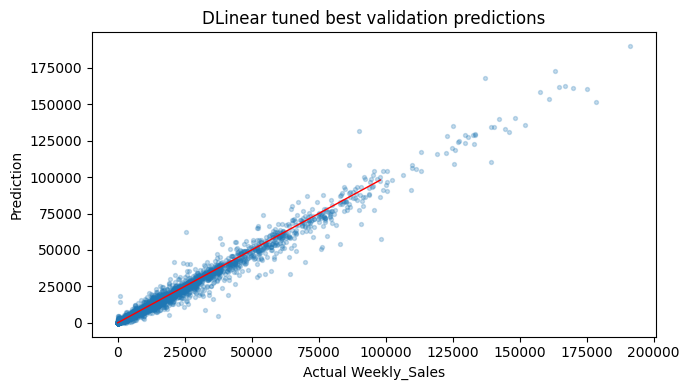

In [ ]:
if best_model is not None:
    checkpoint_path = OUTPUT_DIR / "dlinear_tuned_best_checkpoint.pt"
    torch.save({
        "model_state_dict": best_model.state_dict(),
        "config": CONFIG,
        "best_params": best_params,
        "best_epoch": best_epoch,
        "best_validation_wmae": best_val_result["wmae"],
        "series_index": sales_panel.index.tolist(),
        "train_dates": [str(pd.Timestamp(d).date()) for d in all_train_dates],
        "validation_dates": [str(pd.Timestamp(d).date()) for d in val_dates],
    }, checkpoint_path)

    preds = best_val_result["preds"]
    targets = best_val_result["targets"]
    records = []
    for row_idx, (store, dept) in enumerate(sales_panel.index):
        for horizon_idx, date in enumerate(val_dates):
            records.append({
                "Store": int(store),
                "Dept": int(dept),
                "Date": pd.Timestamp(date),
                "IsHoliday": bool(holiday_by_date.loc[date]),
                "Weekly_Sales": float(targets[row_idx, horizon_idx]),
                "Prediction": float(preds[row_idx, horizon_idx]),
                "AbsError": float(abs(targets[row_idx, horizon_idx] - preds[row_idx, horizon_idx])),
            })
    val_pred_df = pd.DataFrame(records)
    val_pred_path = OUTPUT_DIR / "dlinear_tuned_best_validation_predictions.csv"
    val_pred_df.to_csv(val_pred_path, index=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    sample = val_pred_df.sample(min(5000, len(val_pred_df)), random_state=SEED)
    ax.scatter(sample["Weekly_Sales"], sample["Prediction"], s=8, alpha=0.25)
    max_axis = np.nanpercentile(sample[["Weekly_Sales", "Prediction"]].to_numpy(), 99)
    ax.plot([0, max_axis], [0, max_axis], color="red", linewidth=1)
    ax.set_title("DLinear tuned best validation predictions")
    ax.set_xlabel("Actual Weekly_Sales")
    ax.set_ylabel("Prediction")
    plt.tight_layout()
    plot_path = OUTPUT_DIR / "dlinear_tuned_best_validation_scatter.png"
    fig.savefig(plot_path, dpi=160)
    plt.show()

    artifact = wandb.Artifact("dlinear-tuned-best-series-calibration", type="model")
    artifact.add_file(str(checkpoint_path))
    artifact.add_file(str(summary_path))
    artifact.add_file(str(study_path))
    artifact.add_file(str(val_pred_path))
    artifact.add_file(str(plot_path))

    artifact_run = wandb.init(
        project=CONFIG["wandb_project"],
        entity=CONFIG["wandb_entity"],
        group=CONFIG["wandb_group"],
        job_type="artifact_logging",
        name="dlinear_tuned_best_artifact",
        config={**CONFIG, **best_params, **summary},
        reinit=True,
    )
    artifact_run.log_artifact(artifact, aliases=["tuned-best", "latest"])
    wandb.log({
        "validation/prediction_table": wandb.Table(dataframe=val_pred_df.sample(min(20000, len(val_pred_df)), random_state=SEED)),
        "validation/scatter": wandb.Image(str(plot_path)),
    })
    artifact_run.finish()
else:
    print("Final best training skipped; no model artifact logged.")

## Package selected DLinear as a raw-input pipeline

This section does **not** retrain. It downloads the chosen best checkpoint, stores the historical sales context inside a serializable pipeline, verifies that a reload produces identical predictions, then logs and registers that pipeline in W&B.


In [8]:
class DLinearRawPipeline:
    """Self-contained DLinear pipeline whose public interface accepts raw Walmart test rows."""

    required_raw_columns = {"Store", "Dept", "Date", "IsHoliday"}

    def __init__(self, checkpoint: dict, sales_history: pd.DataFrame):
        self.checkpoint = checkpoint
        self.sales_history = sales_history[["Store", "Dept", "Date", "Weekly_Sales"]].copy()
        self.sales_history["Date"] = pd.to_datetime(self.sales_history["Date"])
        self.sales_history = self.sales_history.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

        raw_index = checkpoint.get("series_index")
        if raw_index is None:
            raise KeyError("Selected checkpoint has no series_index.")
        self.series_index = pd.MultiIndex.from_tuples([tuple(x) for x in raw_index], names=["Store", "Dept"])
        self.series_to_idx = {tuple(map(int, key)): idx for idx, key in enumerate(self.series_index.tolist())}

        state = checkpoint["model_state_dict"]
        self.pred_len, self.input_weeks = map(int, state["linear_trend.weight"].shape)
        params = checkpoint.get("best_params", {})
        saved_config = checkpoint.get("config", {})
        self.moving_avg_kernel = int(params.get("moving_avg_kernel", saved_config.get("moving_avg_kernel", 25)))
        self.model_state_dict = {name: tensor.detach().cpu() for name, tensor in state.items()}

    def _build_model(self) -> nn.Module:
        model = DLinearSeriesCalibration(
            seq_len=self.input_weeks,
            pred_len=self.pred_len,
            n_series=len(self.series_index),
            moving_avg_kernel=self.moving_avg_kernel,
        )
        model.load_state_dict(self.model_state_dict, strict=True)
        model.eval()
        return model

    def predict(self, raw_test: pd.DataFrame) -> np.ndarray:
        missing = self.required_raw_columns.difference(raw_test.columns)
        if missing:
            raise ValueError({"missing_raw_test_columns": sorted(missing)})

        test = raw_test.copy()
        test["Date"] = pd.to_datetime(test["Date"])
        test_dates = pd.Index(sorted(test["Date"].unique()), name="Date")
        if len(test_dates) != self.pred_len:
            raise ValueError(f"Pipeline predicts {self.pred_len} weeks, got {len(test_dates)} test dates.")

        history_dates = pd.Index(sorted(self.sales_history["Date"].unique()), name="Date")
        if len(history_dates) < self.input_weeks:
            raise ValueError("Stored pipeline history is shorter than the model input window.")
        sales_panel = (
            self.sales_history.pivot_table(index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum")
            .reindex(index=self.series_index, columns=history_dates)
            .fillna(0.0)
        )
        values = sales_panel.to_numpy(dtype=np.float32)
        x_last = values[:, -self.input_weeks:]
        means = x_last.mean(axis=1, keepdims=True).astype(np.float32)
        stds = np.maximum(x_last.std(axis=1, keepdims=True).astype(np.float32), 1.0)
        x_norm = ((x_last - means) / stds).astype(np.float32)

        model = self._build_model()
        batch_size = 1024
        pred_batches = []
        with torch.no_grad():
            for start in range(0, len(self.series_index), batch_size):
                end = min(start + batch_size, len(self.series_index))
                x = torch.from_numpy(x_norm[start:end, :, None])
                series_idx = torch.arange(start, end, dtype=torch.long)
                pred_norm = model(x, series_idx).cpu().numpy()
                pred_batches.append(pred_norm * stds[start:end] + means[start:end])
        horizon_predictions = np.clip(np.concatenate(pred_batches, axis=0), 0.0, None)

        prediction_lookup = {}
        for row_idx, (store, dept) in enumerate(self.series_index):
            for horizon_idx, date in enumerate(test_dates):
                prediction_lookup[(int(store), int(dept), pd.Timestamp(date))] = float(horizon_predictions[row_idx, horizon_idx])

        # This is the same explicit cold-start fallback used by the prior DLinear inference run.
        return np.asarray([
            prediction_lookup.get((int(row.Store), int(row.Dept), pd.Timestamp(row.Date)), 0.0)
            for row in test.itertuples(index=False)
        ], dtype=np.float32)

    def metadata(self) -> dict:
        return {
            "pipeline_type": type(self).__name__,
            "input_weeks": self.input_weeks,
            "prediction_weeks": self.pred_len,
            "moving_avg_kernel": self.moving_avg_kernel,
            "stored_series": len(self.series_index),
            "stored_history_rows": len(self.sales_history),
            "raw_input_columns": sorted(self.required_raw_columns),
            "cold_start_fallback": "0.0, matching the selected DLinear inference contract",
        }


In [9]:
if CONFIG["package_selected_raw_pipeline"]:
    package_run = wandb.init(
        project=CONFIG["wandb_project"],
        entity=CONFIG["wandb_entity"],
        group="dlinear-pipeline-packaging",
        job_type="pipeline_packaging",
        name="dlinear_manual_v1_raw_pipeline_registration",
        config={
            "selected_model_artifact_uri": CONFIG["selected_model_artifact_uri"],
            "registry_target": CONFIG["raw_pipeline_registry_target"],
            "raw_input_contract": ["Store", "Dept", "Date", "IsHoliday"],
        },
    )
    source_artifact = package_run.use_artifact(CONFIG["selected_model_artifact_uri"])
    source_dir = Path(source_artifact.download(root=str(OUTPUT_DIR / "selected_source_model")))
    checkpoint_candidates = sorted(source_dir.glob("*.pt"))
    if not checkpoint_candidates:
        raise FileNotFoundError(f"No checkpoint found in source artifact: {source_dir}")
    selected_checkpoint_path = checkpoint_candidates[0]
    selected_checkpoint = torch.load(selected_checkpoint_path, map_location="cpu")

    pipeline = DLinearRawPipeline(selected_checkpoint, train_raw)
    pipeline_path = OUTPUT_DIR / "walmart_dlinear_raw_pipeline.pkl"
    with pipeline_path.open("wb") as file:
        cloudpickle.dump(pipeline, file)

    # Contract test: raw test -> prediction, then reload -> the same prediction.
    original_prediction = pipeline.predict(test_raw)
    with pipeline_path.open("rb") as file:
        reloaded_pipeline = cloudpickle.load(file)
    reloaded_prediction = reloaded_pipeline.predict(test_raw)
    if len(original_prediction) != len(test_raw):
        raise AssertionError("Pipeline prediction length does not match raw test rows.")
    if not np.isfinite(original_prediction).all() or (original_prediction < 0).any():
        raise AssertionError("Pipeline produced non-finite or negative predictions.")
    if not np.allclose(original_prediction, reloaded_prediction, rtol=0.0, atol=1e-5):
        raise AssertionError("Reloaded pipeline predictions differ from the original pipeline.")

    contract_frame = test_raw[["Store", "Dept", "Date"]].copy()
    contract_frame["Weekly_Sales"] = original_prediction
    contract_path = OUTPUT_DIR / "dlinear_raw_pipeline_contract_predictions.csv"
    contract_frame.to_csv(contract_path, index=False)
    prediction_sha256 = hashlib.sha256(original_prediction.tobytes()).hexdigest()

    manifest = {
        "source_model_artifact": source_artifact.name,
        "source_model_artifact_uri": CONFIG["selected_model_artifact_uri"],
        "registry_target": CONFIG["raw_pipeline_registry_target"],
        "pipeline_file": pipeline_path.name,
        "contract_test_rows": int(len(test_raw)),
        "contract_prediction_sha256": prediction_sha256,
        "contract_reload_allclose": True,
        **pipeline.metadata(),
    }
    manifest_path = OUTPUT_DIR / "dlinear_raw_pipeline_manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2))

    pipeline_artifact = wandb.Artifact(
        CONFIG["raw_pipeline_artifact_name"],
        type="model",
        description="Self-contained DLinear raw-input pipeline. predict(raw_test) uses stored history and selected manual-v1 checkpoint.",
        metadata=manifest,
    )
    for artifact_path in [pipeline_path, manifest_path, contract_path]:
        pipeline_artifact.add_file(str(artifact_path))
    package_run.log_artifact(pipeline_artifact, aliases=["manual-v1", "latest"])
    package_run.link_artifact(
        pipeline_artifact,
        target_path=CONFIG["raw_pipeline_registry_target"],
        aliases=["champion", "manual-v1", "latest"],
    )
    package_run.log({
        "pipeline/contract_predictions": wandb.Table(dataframe=contract_frame.head(2000)),
        "pipeline/stored_series": manifest["stored_series"],
        "pipeline/stored_history_rows": manifest["stored_history_rows"],
        "pipeline/contract_test_rows": manifest["contract_test_rows"],
    })
    package_run.summary.update(manifest)
    package_run.finish()
    print({"pipeline_path": str(pipeline_path), "registry_target": CONFIG["raw_pipeline_registry_target"], **pipeline.metadata()})
else:
    print("Pipeline packaging skipped. Set CONFIG['package_selected_raw_pipeline'] = True to register it.")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb:   4 of 4 files downloaded.  


pipeline/contract_test_rows,▁
pipeline/stored_history_rows,▁
pipeline/stored_series,▁
cold_start_fallback,"0.0, matching the se..."
contract_prediction_sha256,dfa09de2ef105a90f9bd...
contract_reload_allclose,True
contract_test_rows,115064
input_weeks,52
moving_avg_kernel,25
pipeline/contract_test_rows,115064
pipeline/stored_history_rows,421570


{'pipeline_path': '/content/artifacts/dlinear_hyperparameter_tuning/walmart_dlinear_raw_pipeline.pkl', 'registry_target': 'wandb-registry-model/Walmart_DLinear_Raw_Pipeline', 'pipeline_type': 'DLinearRawPipeline', 'input_weeks': 52, 'prediction_weeks': 39, 'moving_avg_kernel': 25, 'stored_series': 3331, 'stored_history_rows': 421570, 'raw_input_columns': ['Date', 'Dept', 'IsHoliday', 'Store'], 'cold_start_fallback': '0.0, matching the selected DLinear inference contract'}
